# Climate Clustering Analysis

Organized analysis of learned climate regimes, seasonal patterns, and ENSO response.

In [13]:
import os, sys

if '..' not in sys.path:
    sys.path.append('..')
    os.chdir('..')

import pandas as pd
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as patches
import seaborn as sns
import math

import src.inference as inf
from src.el_nino import read_enso_data

## Configuration

Adjust these parameters before running the notebook.

In [14]:
# ── Model & data paths ──────────────────────────────────────────────────────
VALIDATION   = True
config_file  = 'checkpoint/temperature-run2/params-temperature-exp-2-c30.yaml'
save_path    = 'results/temperature-exp-2-c30'
model_suffix = None  # None = latest checkpoint

# ── Analysis mode ───────────────────────────────────────────────────────────
# 'climatology' : Delta P = P(k | El Nino) - P(k)          (vs overall freq)
# 'neutral'     : Delta P = P(k | El Nino) - P(k | Neutral) (vs neutral cond)
COMPARISON_MODE = 'climatology'

## Data Loading

In [15]:
params, dataset = inf.read_data(config_file, validation=VALIDATION)
target_encoder, prot = inf.load_model(params, model_suffix=model_suffix)

E, F = inf.get_model_results(
    read_path=save_path, params=params, dataset=dataset,
    encoder=target_encoder, prototypes=prot)

if VALIDATION:
    E_val, F_val = inf.get_model_results(
        read_path=save_path, params=params, dataset=dataset.validation_imgs,
        encoder=target_encoder, prototypes=prot, validation=True)

    tsne_E, tsne_prot, tsne_Eval = inf.get_TSNE(
        save_path, E=E.cpu(), prot=prot.cpu(),
        E_val=E_val.cpu() if VALIDATION else None, validation=VALIDATION)

INFO:root:data loader created


Encoding: 100%|██████████| 22645/22645 [01:00<00:00, 375.86it/s]


Saved E and F to results/temperature-exp-2-c30


Encoding: 100%|██████████| 445/445 [00:01<00:00, 444.94it/s]


Saved E and F to results/temperature-exp-2-c30


In [16]:
cluster_prob, cluster_id = torch.max(F, dim=1)
df = pd.DataFrame({
    'cluster_id':   cluster_id.cpu(),
    'cluster_prob': cluster_prob.cpu(),
    'sample_type':  'train',
    'date':         dataset.time,
})

if VALIDATION:
    val_cluster_prob, val_cluster_id = torch.max(F_val, dim=1)
    df_val = pd.DataFrame({
        'cluster_id':   val_cluster_id.cpu(),
        'cluster_prob': val_cluster_prob.cpu(),
        'sample_type':  'val',
        'date':         dataset.val_time,
    })
    df = pd.concat([df, df_val]).sort_values('date').reset_index(drop=True)

    combined_dataset = torch.cat((dataset[:][0], dataset.validation_imgs))[df.index]
    tsne = np.concatenate((tsne_E, tsne_Eval))[df.index]

    mean = torch.tensor(params['data']['norm_means']).view(2, 1, 1)
    std  = torch.tensor(params['data']['norm_stds']).view(2, 1, 1)
    combined_dataset = (combined_dataset * std) + mean
else:
    combined_dataset = dataset[:][0]

# Shared metadata
nvars      = combined_dataset.shape[1]
N_PROTO    = params['criterion']['num_proto']
vars_names = params['data']['surf_vars']
var_stats  = {v: (combined_dataset[:, v].min(), combined_dataset[:, v].max()) for v in range(nvars)}

# Merge ENSO labels
oni_index  = read_enso_data()
df['date_period'] = df['date'].dt.to_period('M')
df_el_nino = df.copy()
df_el_nino = df_el_nino.merge(oni_index, left_on='date_period', right_index=True, how='left')
df_el_nino[['Average Tmin', 'Average Tmax']] = combined_dataset.mean(dim=(2, 3))

# Colour palette (30 clusters)
PALETTE30 = sns.color_palette('tab20', 20) + sns.color_palette('bright', 10)

## 1. Embedding Space (t-SNE)

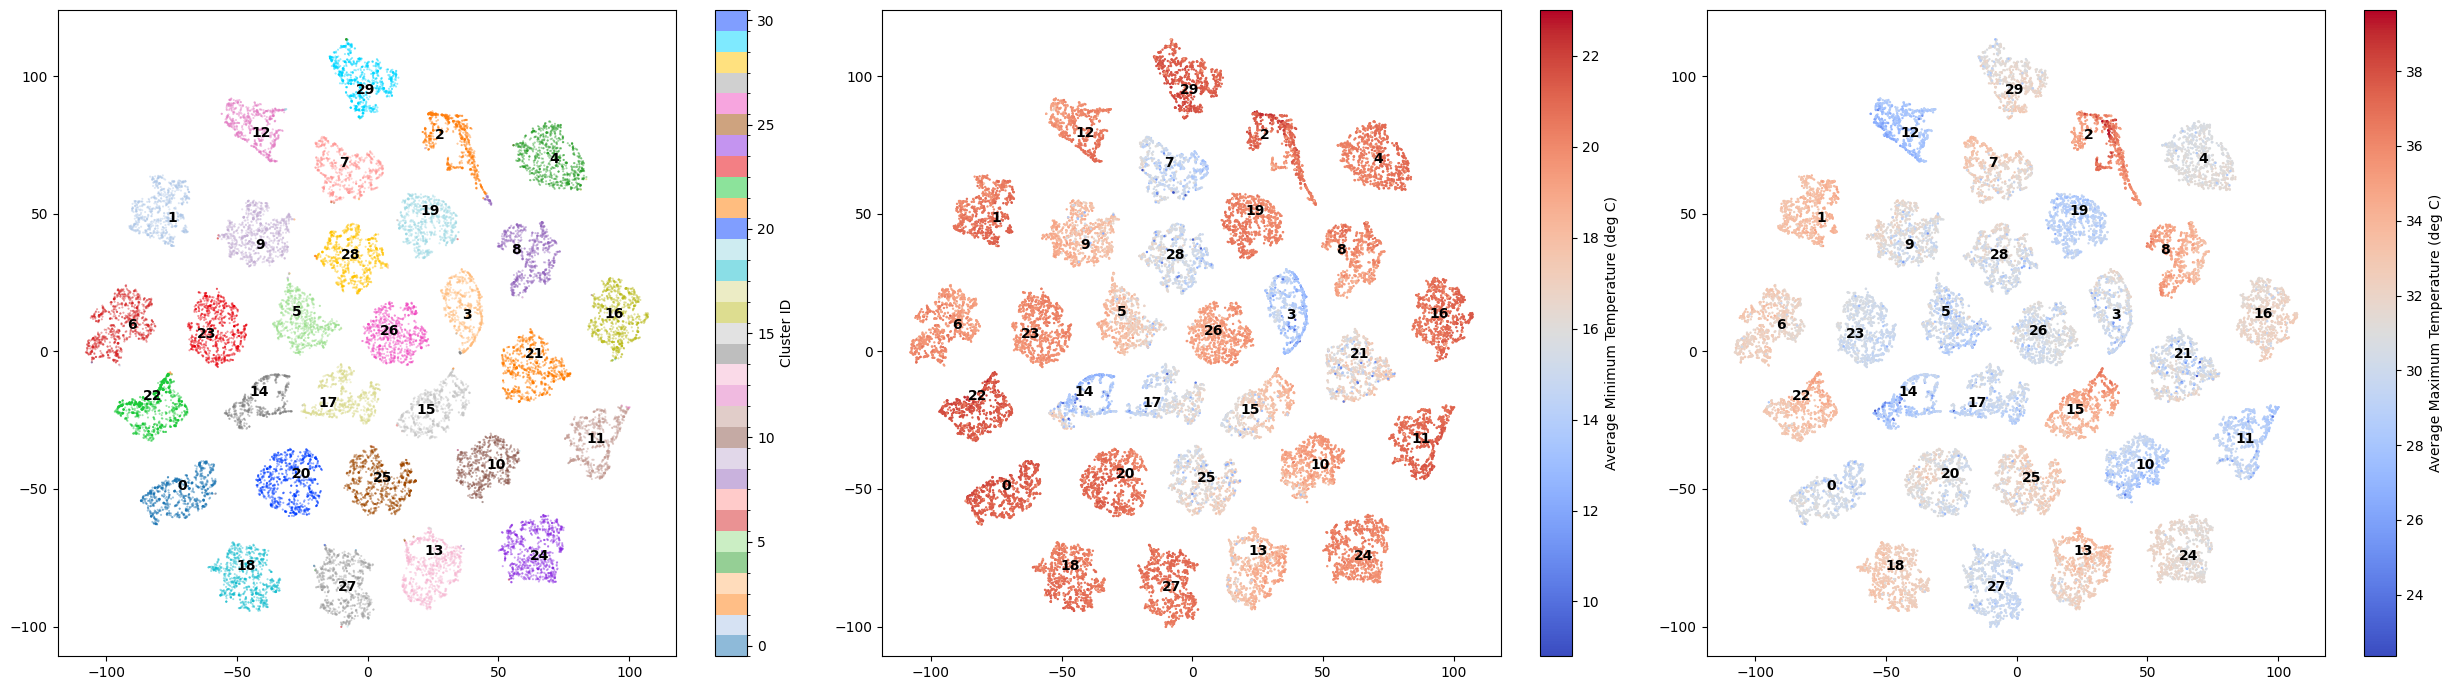

In [17]:
def plot_tsne(tsne_E, tsne_Eval, tsne_prot, F, F_val, df_el_nino, VALIDATION=True):
    pallete31 = sns.color_palette('tab20', 20) + sns.color_palette('bright', 11)
    cmap_clusters = mcolors.ListedColormap(pallete31)
    bounds = np.arange(-0.5, 31.5, 1)
    norm   = mcolors.BoundaryNorm(bounds, cmap_clusters.N)

    fig, axs = plt.subplots(1, 3, figsize=(25, 7))

    # --- Panel 1: Cluster IDs ---
    cluster_labels = F.argmax(axis=1).cpu().numpy()
    sc1 = axs[0].scatter(tsne_E[:, 0], tsne_E[:, 1], c=cluster_labels,
                         cmap=cmap_clusters, norm=norm, s=0.2, alpha=0.5)
    if VALIDATION:
        cluster_labels_val = F_val.argmax(axis=1).cpu().numpy()
        axs[0].scatter(tsne_Eval[:, 0], tsne_Eval[:, 1], c=cluster_labels_val,
                       cmap=cmap_clusters, norm=norm, s=1)
    fig.colorbar(sc1, ax=axs[0], ticks=np.arange(0, 31, 5)).set_label('Cluster ID')

    # --- Panel 2 & 3: Temperature ---
    for ax_idx, (col, label) in enumerate([
        ('Average Tmin', 'Average Minimum Temperature (deg C)'),
        ('Average Tmax', 'Average Maximum Temperature (deg C)'),
    ]):
        ax = axs[ax_idx + 1]
        train_vals = df_el_nino[df_el_nino['sample_type'] == 'train'][col].values
        sc = ax.scatter(tsne_E[:, 0], tsne_E[:, 1], c=train_vals, cmap='coolwarm', s=0.5)
        if VALIDATION:
            val_vals = df_el_nino[df_el_nino['sample_type'] == 'val'][col].values
            ax.scatter(tsne_Eval[:, 0], tsne_Eval[:, 1], c=val_vals, cmap='coolwarm', s=0.5)
        fig.colorbar(sc, ax=ax, label=label)

    for ax in axs:
        for i, (x, y) in enumerate(tsne_prot):
            ax.text(x, y, str(i), color='black', fontsize=10,
                    ha='center', va='center', weight='bold')

    plt.tight_layout()
    plt.show()


plot_tsne(tsne_E, tsne_Eval, tsne_prot, F, F_val, df_el_nino, VALIDATION)


## 2. Cluster Prototypes

Top-*k* training samples per cluster, ordered by assignment probability.

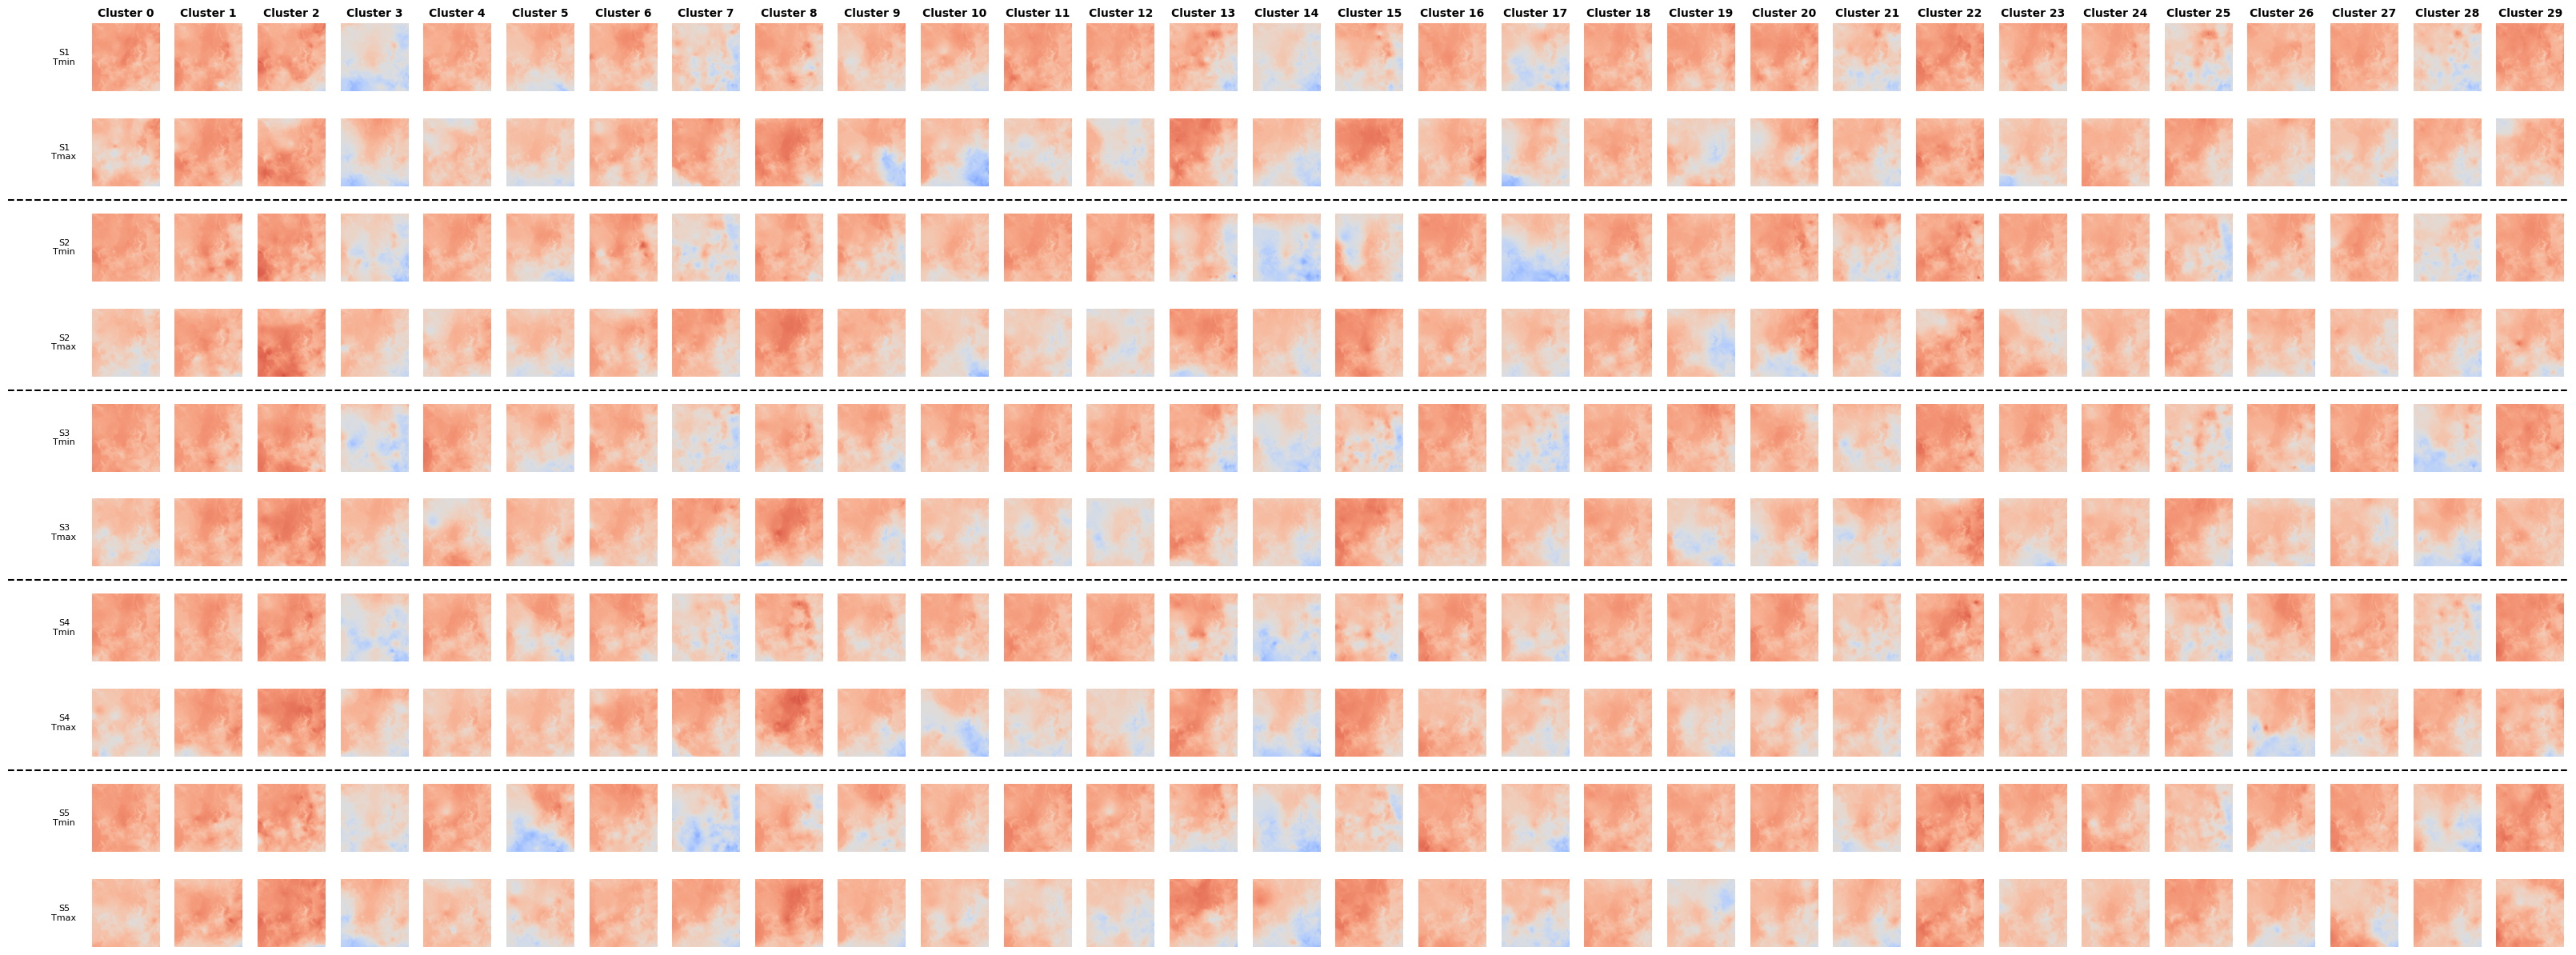

In [18]:
def plot_cluster_prototypes(df, combined_dataset, N_PROTO, nvars, vars_names, var_stats, top=5):
    n_rows = top * nvars
    fig, axes = plt.subplots(n_rows, N_PROTO, figsize=(40, 15))
    plt.subplots_adjust(hspace=0.4, wspace=0.1)

    for i in range(N_PROTO):
        top_samples = df[(df['cluster_id'] == i) & (df['sample_type'] == 'train')]\
            .nlargest(top, 'cluster_prob')
        for s_idx, im_index in enumerate(top_samples.index):
            image_data = combined_dataset[im_index]
            for var in range(nvars):
                ax = axes[s_idx * nvars + var, i]
                vmin, vmax = var_stats[var]
                ax.imshow(image_data[var], cmap='coolwarm', vmin=vmin, vmax=vmax)
                if s_idx * nvars + var == 0:
                    ax.set_title(f'Cluster {i}', fontsize=10, fontweight='bold')
                if i == 0:
                    ax.set_ylabel(f'S{s_idx+1}\n{vars_names[var]}',
                                  rotation=0, labelpad=25, va='center', fontsize=8)

    # Horizontal dividers between samples
    for r in range(nvars, n_rows, nvars):
        upper_ax = axes[r - 1, 0].get_position()
        lower_ax = axes[r,     0].get_position()
        y_pos = (upper_ax.y0 + lower_ax.y1) / 2
        fig.add_artist(plt.Line2D([0.1, 0.9], [y_pos, y_pos],
                                  transform=fig.transFigure,
                                  color='black', linewidth=1.5, linestyle='--'))

    for ax in axes.flatten():
        ax.set_xticks([]); ax.set_yticks([])
        for spine in ax.spines.values(): spine.set_visible(False)

    plt.show()


plot_cluster_prototypes(df, combined_dataset, N_PROTO, nvars, vars_names, var_stats, top=5)


## 3. Seasonal Analysis

In [19]:
# ── Helper: assign Southern-Hemisphere seasons ──────────────────────────────
def get_season(date):
    m, d = date.month, date.day
    if (m == 12 and d >= 21) or m in (1, 2) or (m == 3 and d <= 20):  return 'Summer'
    elif (m == 3 and d >= 21) or m in (4, 5) or (m == 6 and d <= 20): return 'Autumn'
    elif (m == 6 and d >= 21) or m in (7, 8) or (m == 9 and d <= 22): return 'Winter'
    else: return 'Spring'


def compute_seasonal_groups(df):
    """Assign each cluster to its dominant season and return the grouping map."""
    df = df.copy()
    df['season'] = df['date'].apply(get_season)
    seasonal_dist = pd.crosstab(df['cluster_id'], df['season'], normalize='index')
    seasonal_dist['dominant_season'] = seasonal_dist.idxmax(axis=1)
    grupos = (seasonal_dist.reset_index()
              .groupby('dominant_season')
              .apply(lambda x: x['cluster_id'].tolist(), include_groups=False)
              .to_dict())
    return df, grupos


df, grupos_map_season = compute_seasonal_groups(df)


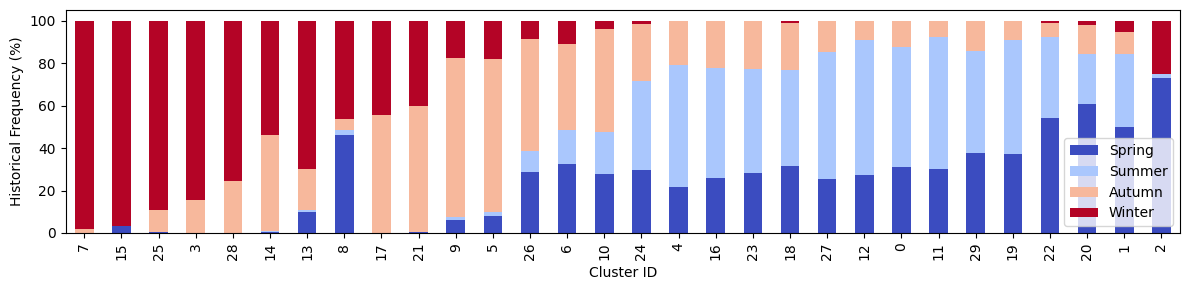

In [20]:
def plot_seasonal_composition(df, order=None):
    """Stacked bar chart: seasonal composition of each cluster.
    Returns the cluster order used."""
    season_order = ['Winter', 'Autumn', 'Summer', 'Spring']
    df = df.copy()
    if 'season' not in df.columns:
        df['season'] = df['date'].apply(get_season)

    seasonal_dist = pd.crosstab(df['cluster_id'], df['season'], normalize='index') * 100

    if order is None:
        seasonal_dist['dominant'] = pd.Categorical(
            seasonal_dist.idxmax(axis=1), categories=season_order[::-1], ordered=True)
        order_map = {s: i for i, s in enumerate(season_order[::-1])}
        seasonal_dist['season_score'] = seasonal_dist.apply(
            lambda row: sum(row[s] * order_map[s] for s in season_order[::-1]), axis=1)
        seasonal_dist.loc[seasonal_dist['dominant'] == 'Spring', 'season_score'] *= -1
        seasonal_dist = seasonal_dist.sort_values(['dominant', 'season_score'])
    else:
        seasonal_dist = seasonal_dist.loc[order]

    seasonal_dist[::-1][['Spring', 'Summer', 'Autumn', 'Winter']].plot(
        kind='bar', stacked=True, figsize=(12, 3), colormap='coolwarm')
    plt.ylabel('Historical Frequency (%)')
    plt.xlabel('Cluster ID')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()
    return list(seasonal_dist.index)


cluster_order = plot_seasonal_composition(df)


In [21]:
def plot_quantile_by_group(groups, df, combined_dataset, vars_names, n_quantiles=200):
    """Q-Q style deviation from global distribution, per seasonal group."""
    q = np.linspace(0.01, 0.99, n_quantiles)
    linestyles = ['solid', 'dashed', 'dotted', 'dashdot']

    fig, axes = plt.subplots(2, len(groups) // 2, figsize=(10, 7), sharey=True)
    axes = np.atleast_1d(axes)

    for var in range(len(vars_names)):
        global_q = np.quantile(combined_dataset[:, var].ravel(), q)
        for ax_id, (name, group) in enumerate(groups.items()):
            ax = axes.flatten()[ax_id]
            colors = sns.color_palette('bright', n_colors=len(group))
            for g, color in zip(group, colors):
                idx  = df[df['cluster_id'] == g].index.values
                data = combined_dataset[:, var][idx].ravel()
                ax.plot(q, np.quantile(data, q) - global_q,
                        alpha=0.5, color=color, linestyle=linestyles[var])
            ax.axhline(0, color='black', lw=0.8)
            ax.set_xlabel('Quantile')
            ax.set_title(f'{name} Clusters')
            ax.legend(group, loc='upper right')

    axes.flatten()[0].set_ylabel('Delta Quantile (Cluster - Global) in C')
    var_handles = [plt.Line2D([0], [0], color='black', lw=2, linestyle=linestyles[v])
                   for v in range(len(vars_names))]
    fig.legend(var_handles, vars_names, loc='upper right', ncol=len(vars_names))
    plt.tight_layout()
    plt.show()


# plot_quantile_by_group(grupos_map_season, df, combined_dataset, vars_names)

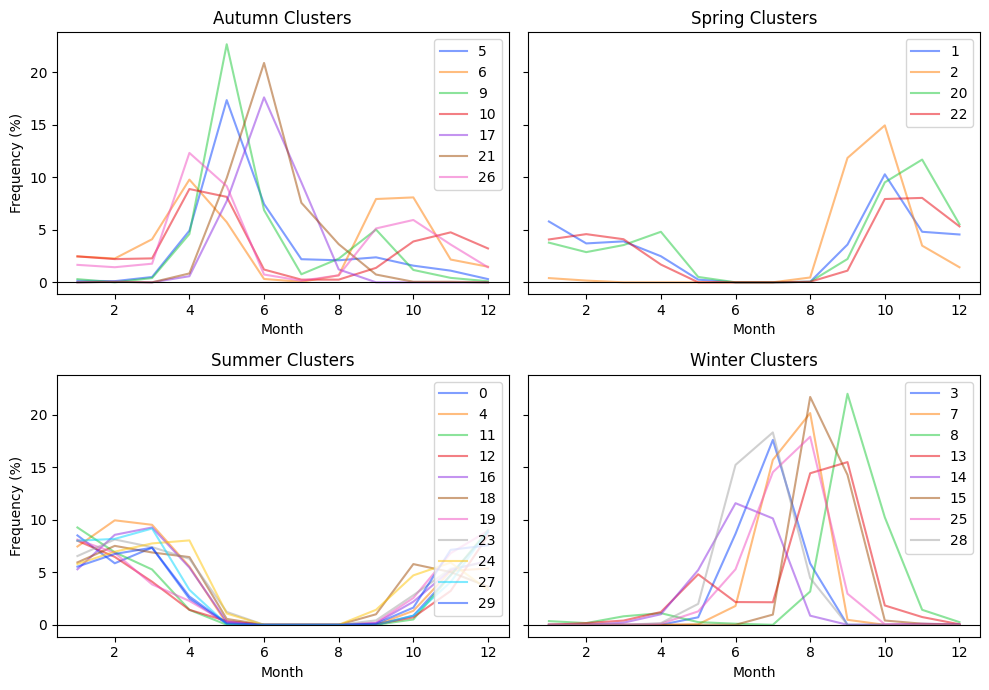

In [22]:
def plot_monthly_frequency(groups, df):
    """Monthly occurrence frequency (%) for each cluster group."""
    cur_df = df.copy()
    cur_df['month'] = cur_df['date'].dt.month
    month_freq = pd.crosstab(cur_df['month'], cur_df['cluster_id'], normalize='index') * 100

    fig, axes = plt.subplots(2, len(groups) // 2, figsize=(10, 7), sharey=True)
    axes = np.atleast_1d(axes)

    for ax_id, (name, group) in enumerate(groups.items()):
        ax = axes.flatten()[ax_id]
        month_freq[group].plot(
            ax=ax, alpha=0.5,
            color=sns.color_palette('bright', n_colors=len(group)))
        ax.axhline(0, color='black', lw=0.8)
        ax.set_xlabel('Month')
        ax.set_title(f'{name} Clusters')
        ax.legend(group, loc='upper right')

    for ax in axes.flatten()[::2]:
        ax.set_ylabel('Frequency (%)')
    plt.tight_layout()
    plt.show()


plot_monthly_frequency(grupos_map_season, df)


## 4. ENSO Analysis

All anomaly plots respect `COMPARISON_MODE`:
- `'climatology'` : $\Delta P_k = P(k \mid \text{El Niño}) - P(k)$
- `'neutral'`     : $\Delta P_k = P(k \mid \text{El Niño}) - P(k \mid \text{Neutral})$

In [23]:
def compute_anomaly(data, comparison_mode):
    """Return per-cluster probability anomaly Series.

    Parameters
    ----------
    data : DataFrame with 'Label' and 'cluster_id' columns
    comparison_mode : 'climatology' or 'neutral'
    """
    prob = pd.crosstab(data['Label'], data['cluster_id'], normalize='index') * 100
    if 'El Nino' not in prob.index and 'El Niño' not in prob.index:
        raise ValueError('No El Nino rows found')
    nino_label = 'El Niño' if 'El Niño' in prob.index else 'El Nino'
    p_nino = prob.loc[nino_label]

    if comparison_mode == 'climatology':
        baseline = data['cluster_id'].value_counts(normalize=True) * 100
        baseline = baseline.reindex(p_nino.index, fill_value=0)
    else:  # neutral
        neutro_label = 'Neutro' if 'Neutro' in prob.index else 'Neutral'
        baseline = prob.loc[neutro_label]

    return p_nino - baseline


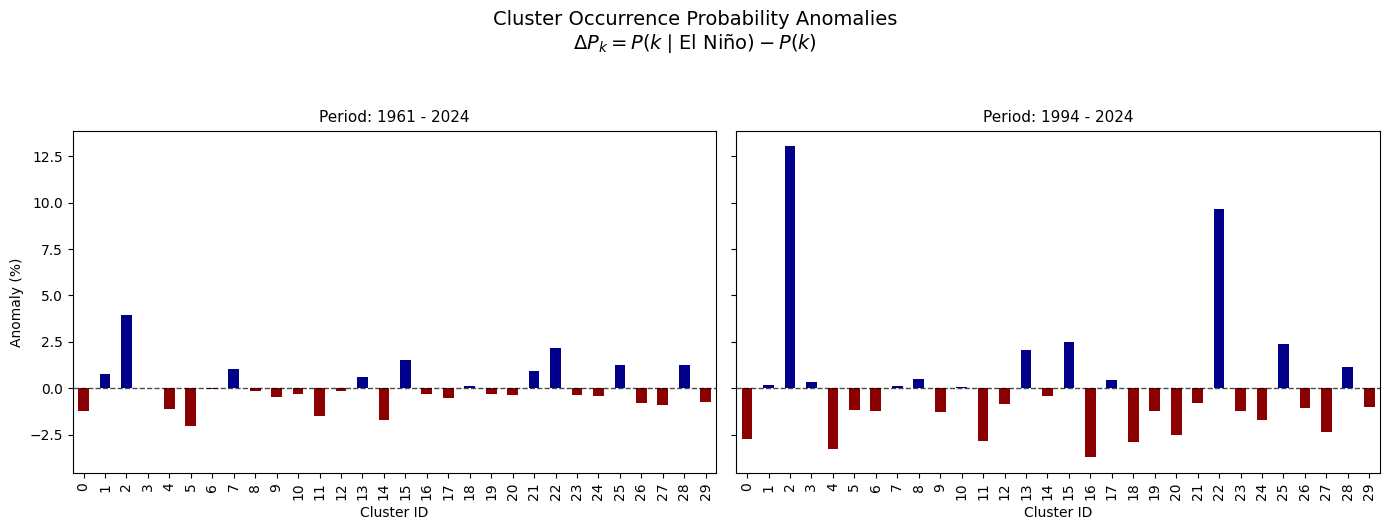

In [24]:
def plot_enso_anomaly_bar(df_el_nino, comparison_mode='climatology',
                           periods=None):
    """Bar chart of cluster probability anomaly for one or two time periods.

    Parameters
    ----------
    periods : list of (start_year, end_year) or None (uses full range + 1994-2024)
    """
    if periods is None:
        full_start = int(df_el_nino['date'].dt.year.min())
        full_end   = int(df_el_nino['date'].dt.year.max())
        periods = [(full_start, full_end), (1994, 2024)]

    datasets = []
    for start, end in periods:
        mask = (df_el_nino['date'].dt.year >= start) & (df_el_nino['date'].dt.year <= end)
        datasets.append((df_el_nino[mask], start, end))

    if comparison_mode == 'climatology':
        formula = r'$\Delta P_k = P(k \mid \text{El Niño}) - P(k)$'
    else:
        formula = r'$\Delta P_k = P(k \mid \text{El Niño}) - P(k \mid \text{Neutral})$'

    fig, axes = plt.subplots(1, len(datasets), figsize=(7 * len(datasets), 5), sharey=True)
    if len(datasets) == 1:
        axes = [axes]
    fig.suptitle('Cluster Occurrence Probability Anomalies\n' + formula,
                 fontsize=14, y=1.05)

    for ax, (data, start, end) in zip(axes, datasets):
        anomaly = compute_anomaly(data, comparison_mode)
        colors  = ['darkblue' if v >= 0 else 'darkred' for v in anomaly]
        anomaly.plot(kind='bar', color=colors, ax=ax)
        ax.axhline(0, color='black', lw=1, linestyle='--', alpha=0.7)
        ax.set_title(f'Period: {start} - {end}', fontsize=11)
        ax.set_xlabel('Cluster ID')
        ax.set_ylabel('Anomaly (%)')

    plt.tight_layout()
    plt.show()


plot_enso_anomaly_bar(df_el_nino, comparison_mode=COMPARISON_MODE)


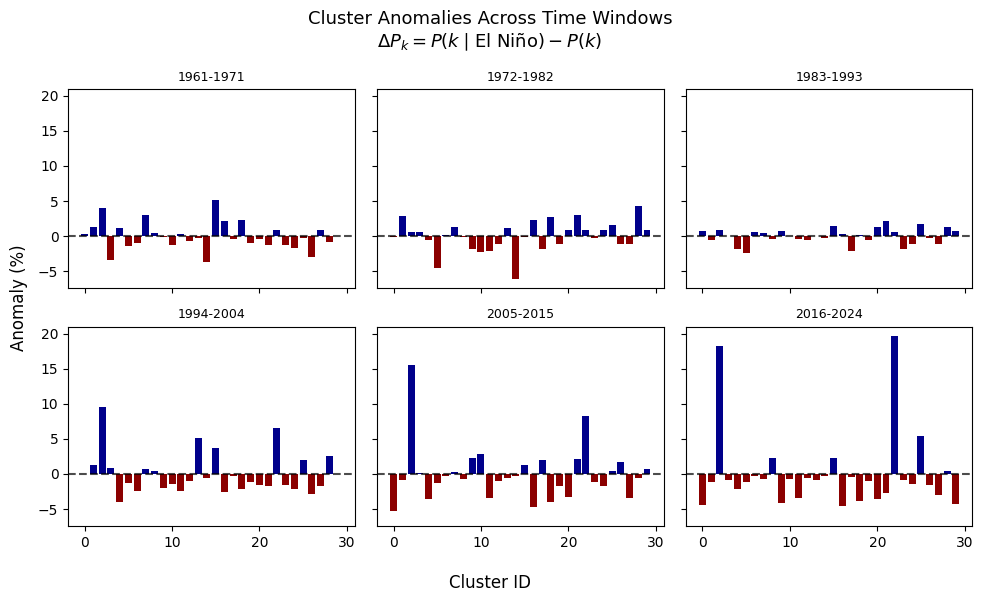

In [25]:
def plot_enso_anomaly_over_time(df_el_nino, comparison_mode='climatology', window_size=11):
    """Small-multiple bar charts across sliding time windows."""
    years = range(int(df_el_nino['date'].dt.year.min()),
                  int(df_el_nino['date'].dt.year.max()), window_size)
    all_vals, labels = [], []

    for start_year in years:
        end_year = start_year + window_size
        cur = df_el_nino[
            (df_el_nino['date'].dt.year >= start_year) &
            (df_el_nino['date'].dt.year < (end_year if end_year < 2024 else 2025))]
        if len(cur) == 0:
            continue
        try:
            anomaly = compute_anomaly(cur, comparison_mode)
        except (ValueError, KeyError):
            continue
        all_vals.append(anomaly)
        labels.append(f"{start_year}-{cur['date'].dt.year.max()}")

    df_anom = pd.DataFrame(all_vals, index=labels)
    n_cols  = 3
    n_rows  = math.ceil(len(df_anom) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 3 * n_rows),
                             sharey=True, sharex=True)
    axes = axes.flatten()

    for i, (label, vals) in enumerate(df_anom.iterrows()):
        colors = ['darkblue' if v >= 0 else 'darkred' for v in vals]
        axes[i].bar(vals.index, vals.values, color=colors)
        axes[i].axhline(0, color='black', linestyle='--', alpha=0.7)
        axes[i].set_title(label, fontsize=9)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    if comparison_mode == 'climatology':
        formula = r'$\Delta P_k = P(k \mid \text{El Niño}) - P(k)$'
    else:
        formula = r'$\Delta P_k = P(k \mid \text{El Niño}) - P(k \mid \text{Neutral})$'

    fig.suptitle('Cluster Anomalies Across Time Windows\n' + formula, fontsize=13)
    fig.supxlabel('Cluster ID')
    fig.supylabel('Anomaly (%)')
    plt.tight_layout()
    plt.show()


plot_enso_anomaly_over_time(df_el_nino, comparison_mode=COMPARISON_MODE)


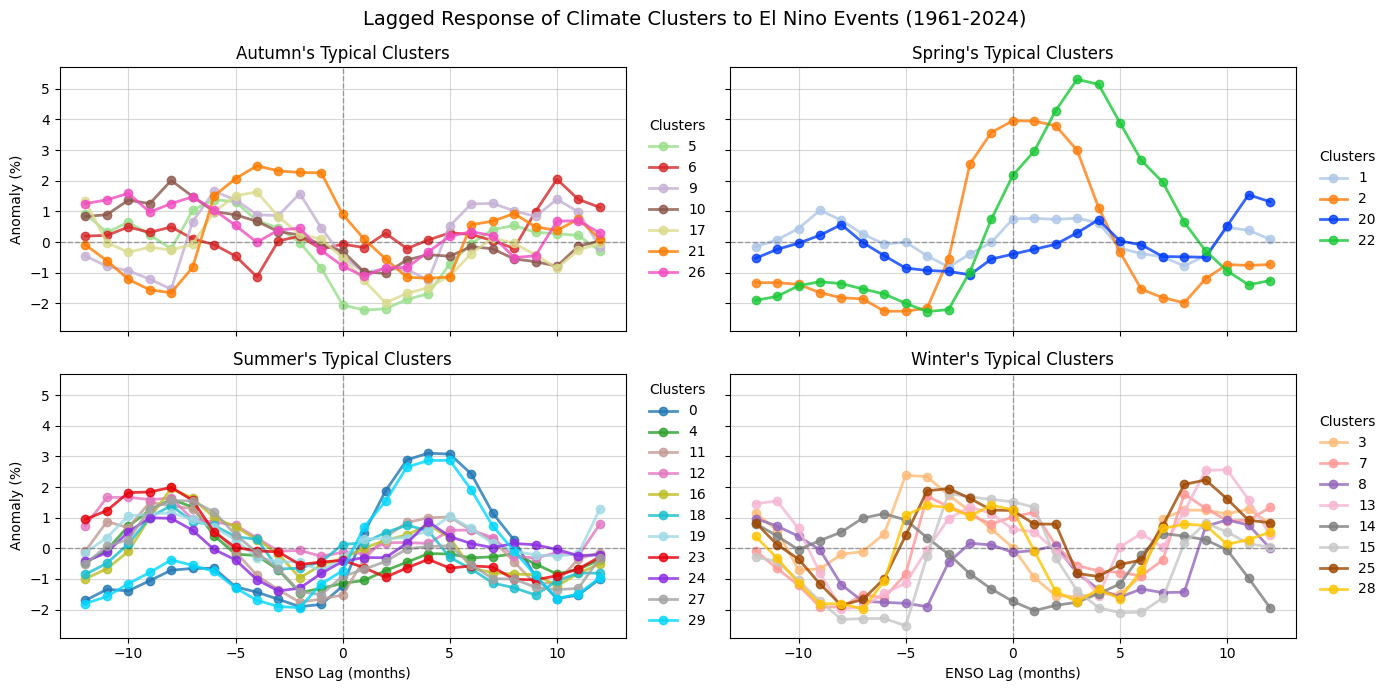

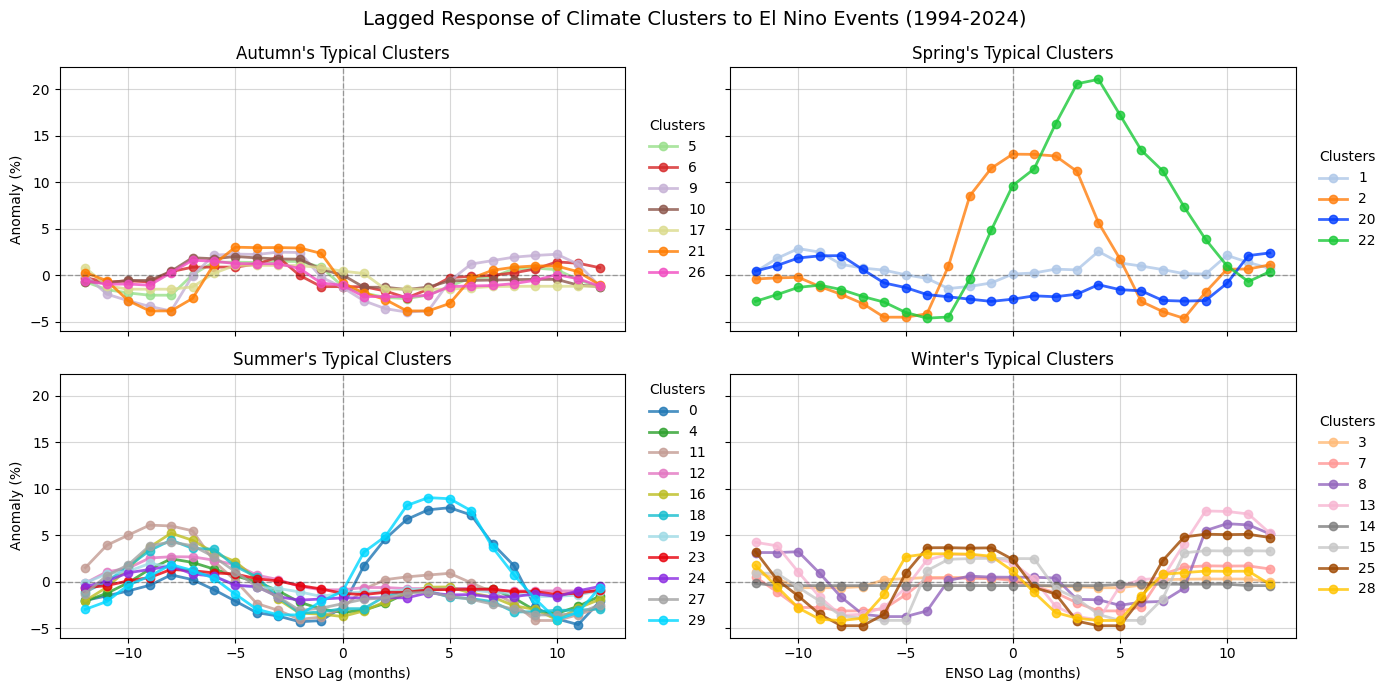

In [26]:
def get_lagged_anomaly(df, oni_index, comparison_mode='neutral'):
    """Compute cluster probability anomaly for each ENSO lag (-12 to +12 months).

    Parameters
    ----------
    comparison_mode : 'neutral' uses P(k|El Nino) - P(k|Neutral);
                      'climatology' uses P(k|El Nino) - P(k)
    """
    anomalias = {}
    for lag in range(-12, 13):
        merged = df.merge(oni_index.shift(lag).dropna(),
                          left_on='date_period', right_index=True, how='left')
        try:
            anomalias[lag] = compute_anomaly(merged, comparison_mode)
        except (ValueError, KeyError):
            continue
    anom = pd.DataFrame(anomalias).sort_index(axis=1)
    anom.columns.name = 'Lag'
    return anom


def plot_lagged_enso_response(df, oni_index, grupos_map_season,
                              comparison_mode='neutral', year_filter=None):
    """Line plot of lagged ENSO anomaly per seasonal cluster group.

    Parameters
    ----------
    year_filter : (start_year, end_year) tuple or None for full range
    """
    cur_df = df.copy()
    if year_filter:
        cur_df = cur_df[cur_df['date'].dt.year.between(*year_filter)]

    anom = get_lagged_anomaly(cur_df, oni_index, comparison_mode)

    fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharex=True, sharey=True)
    axes = axes.flatten()

    for idx, (season, cur_clusters) in enumerate(grupos_map_season.items()):
        anom.T[cur_clusters].plot(
            marker='o', lw=2, alpha=0.8, ax=axes[idx],
            color=[PALETTE30[i] for i in cur_clusters])
        axes[idx].axhline(0, color='black', lw=1, linestyle='--', alpha=0.3)
        axes[idx].axvline(0, color='black', lw=1, linestyle='--', alpha=0.3)
        axes[idx].grid(True, alpha=0.5)
        axes[idx].set_title(f"{season}'s Typical Clusters")
        axes[idx].set_ylabel('Anomaly (%)')
        axes[idx].set_xlabel('ENSO Lag (months)')
        axes[idx].legend(loc='center left', bbox_to_anchor=(1.02, 0.5),
                         frameon=False, title='Clusters')

    year_s = cur_df['date'].dt.year.min()
    year_e = cur_df['date'].dt.year.max()
    fig.suptitle(f'Lagged Response of Climate Clusters to El Nino Events ({year_s}-{year_e})',
                 fontsize=14)
    plt.tight_layout()
    plt.show()


# Full period
plot_lagged_enso_response(df, oni_index, grupos_map_season,
                          comparison_mode=COMPARISON_MODE)
# Recent period
plot_lagged_enso_response(df, oni_index, grupos_map_season,
                          comparison_mode=COMPARISON_MODE, year_filter=(1994, 2024))


### Monthly Lagged Heatmaps

Two complementary views of the month × lag interaction:
- **Per cluster** – rows = month, cols = lag
- **Per month** – rows = cluster, cols = lag

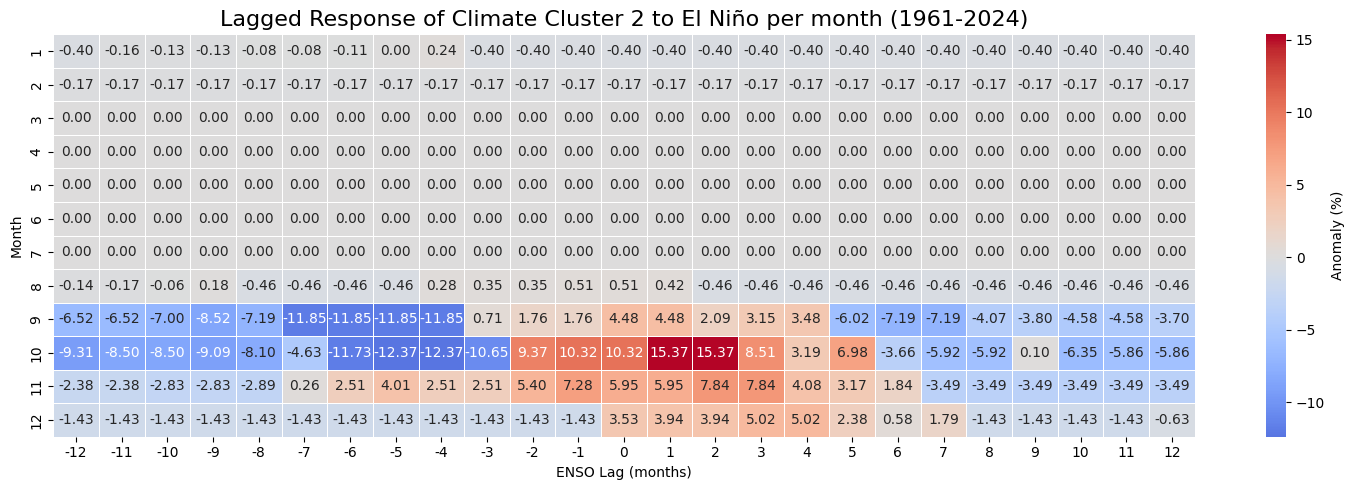

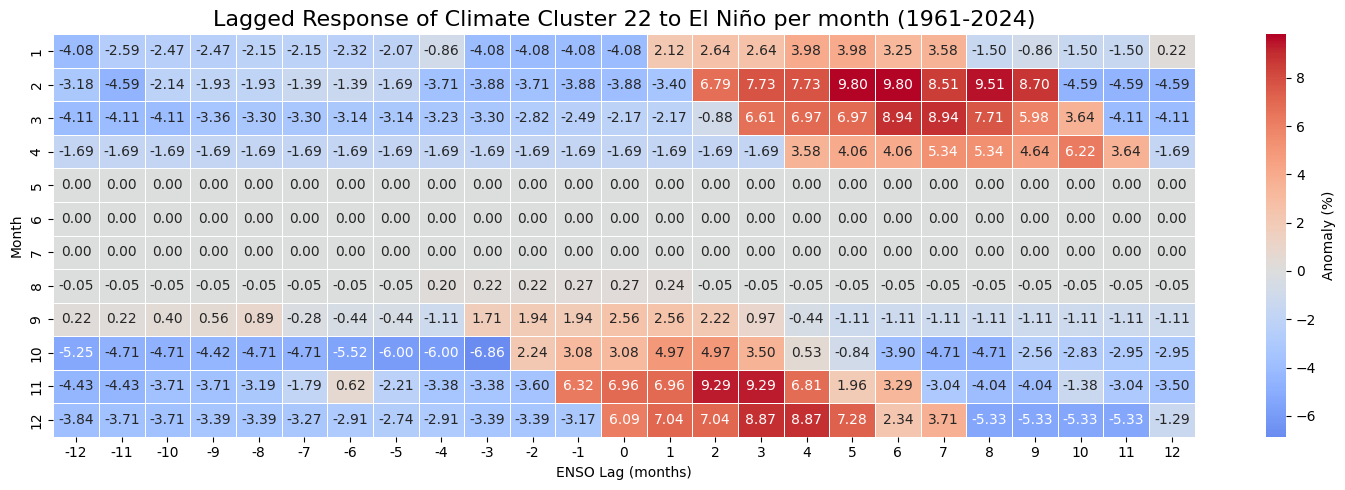

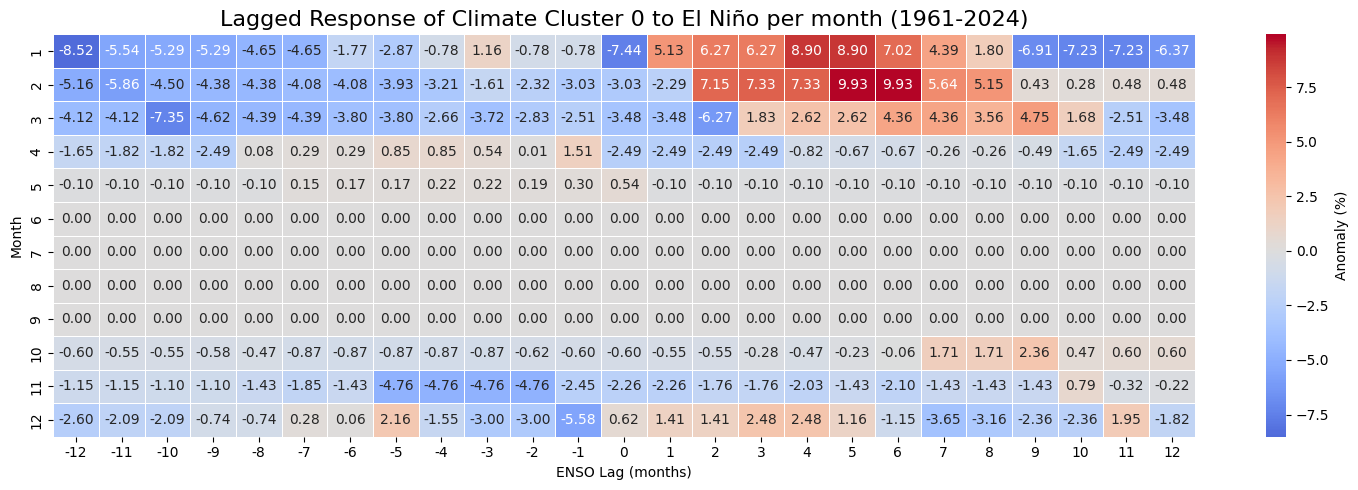

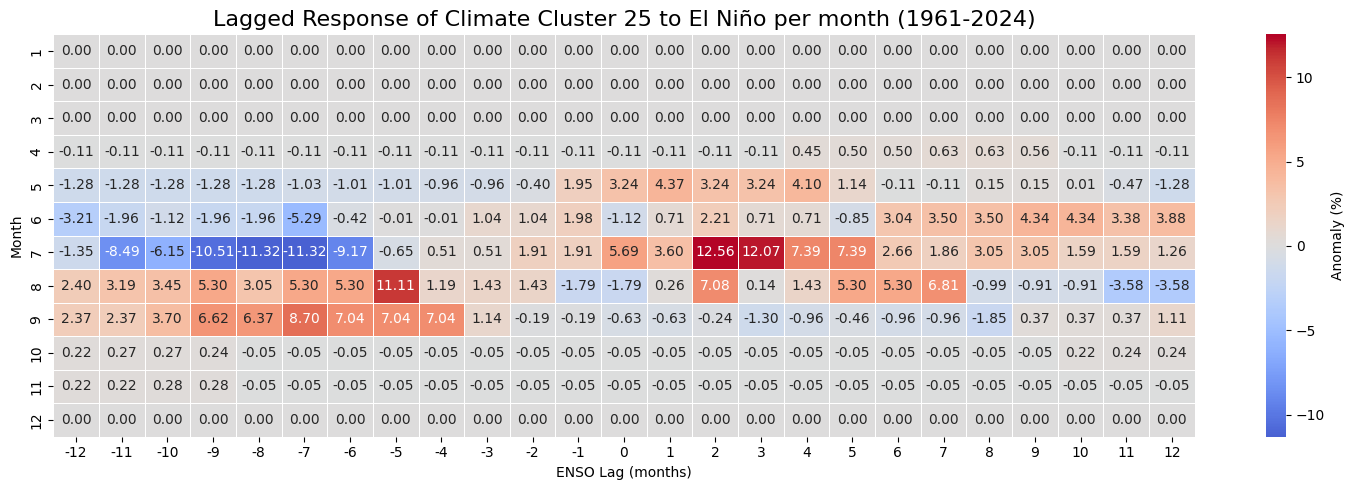

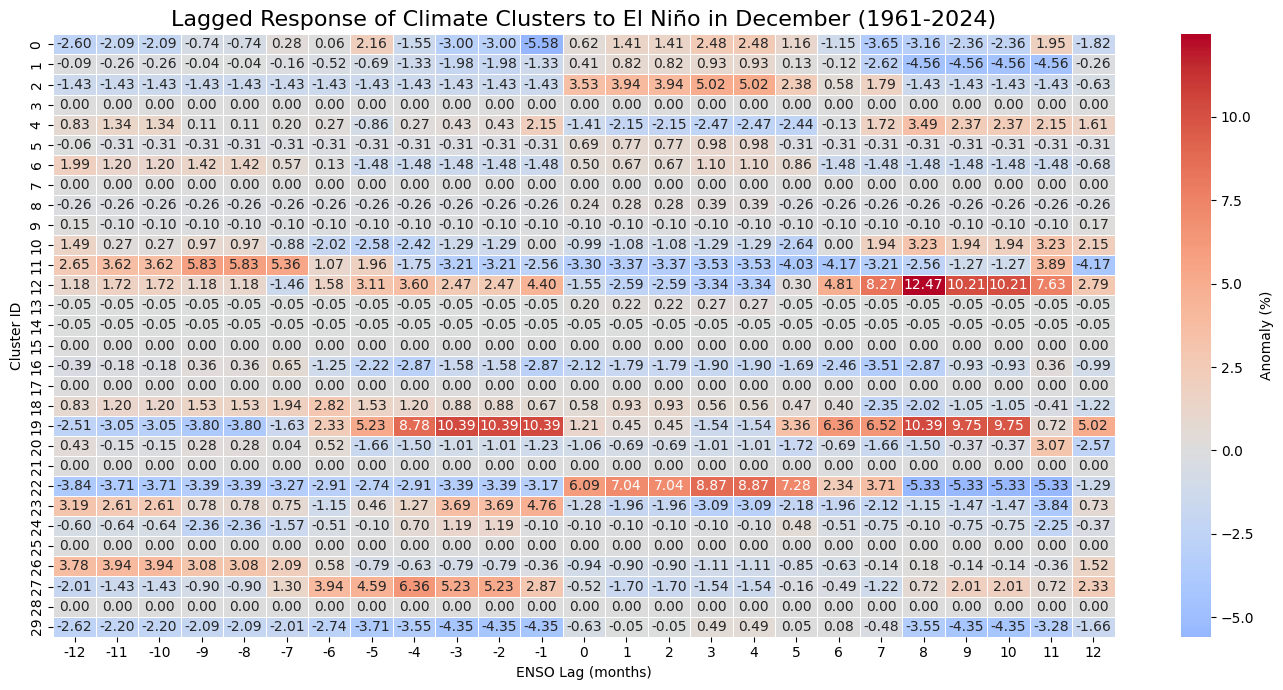

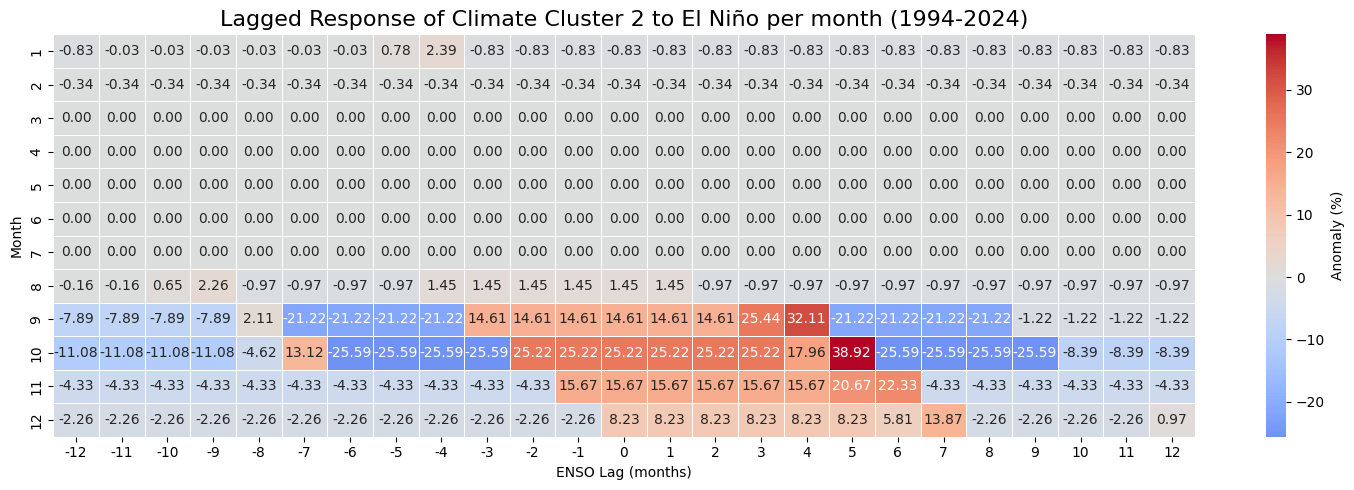

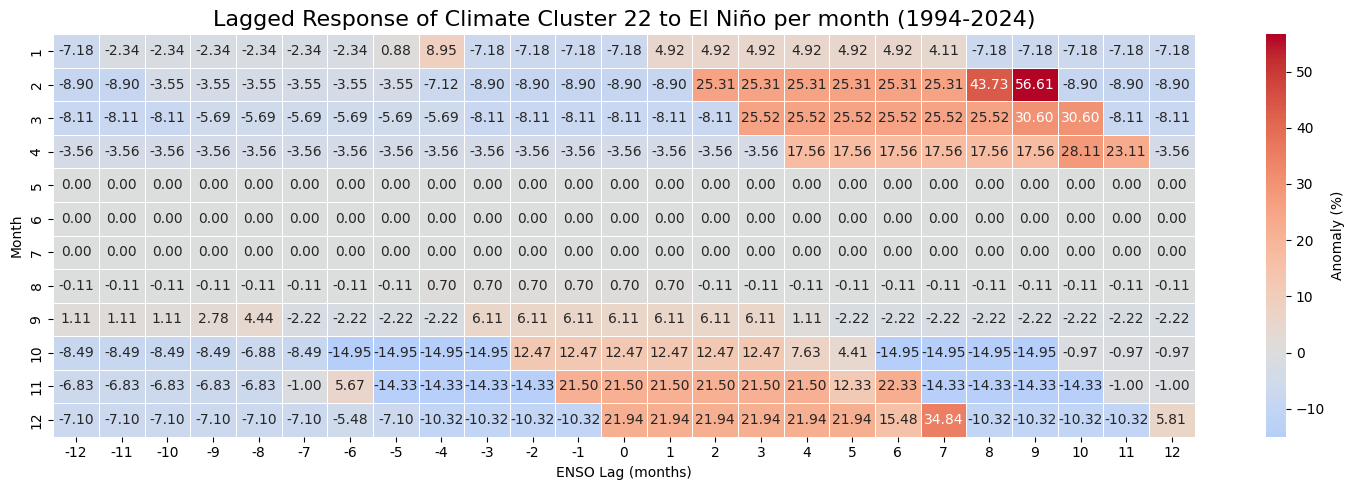

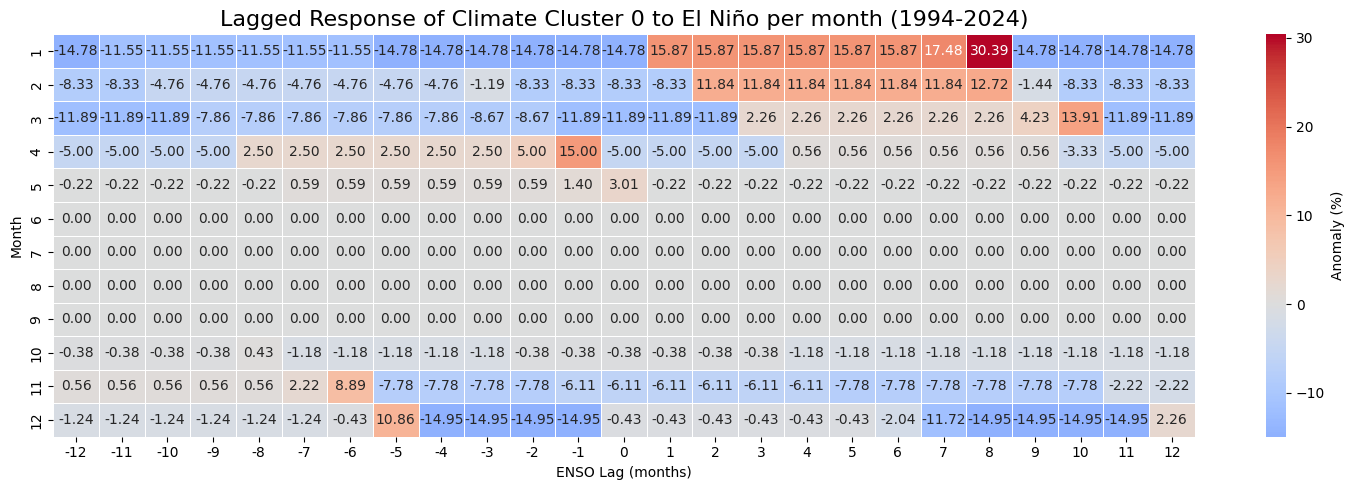

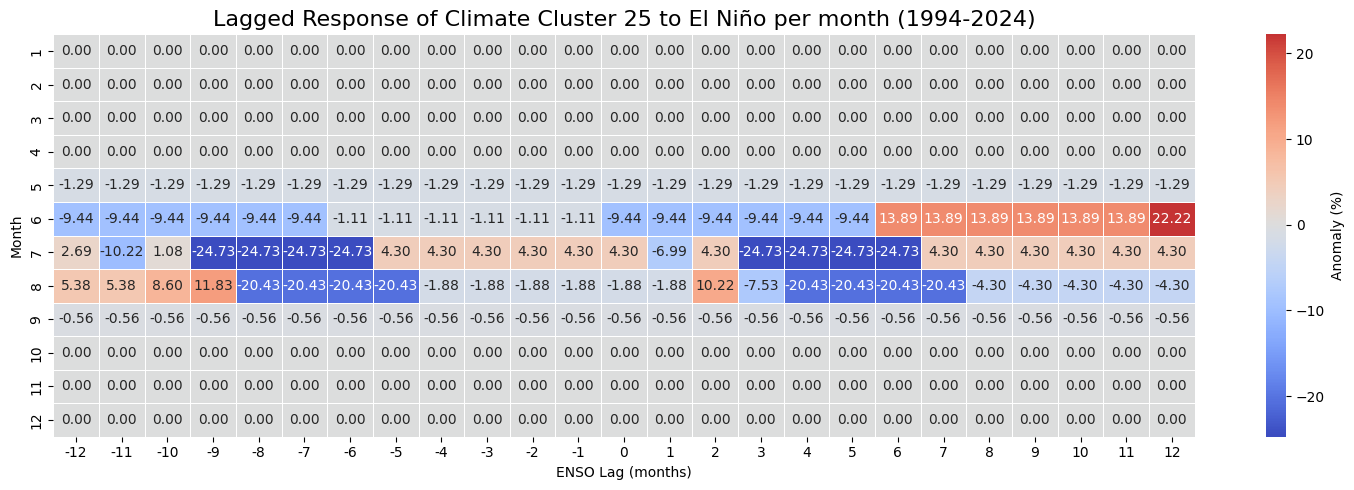

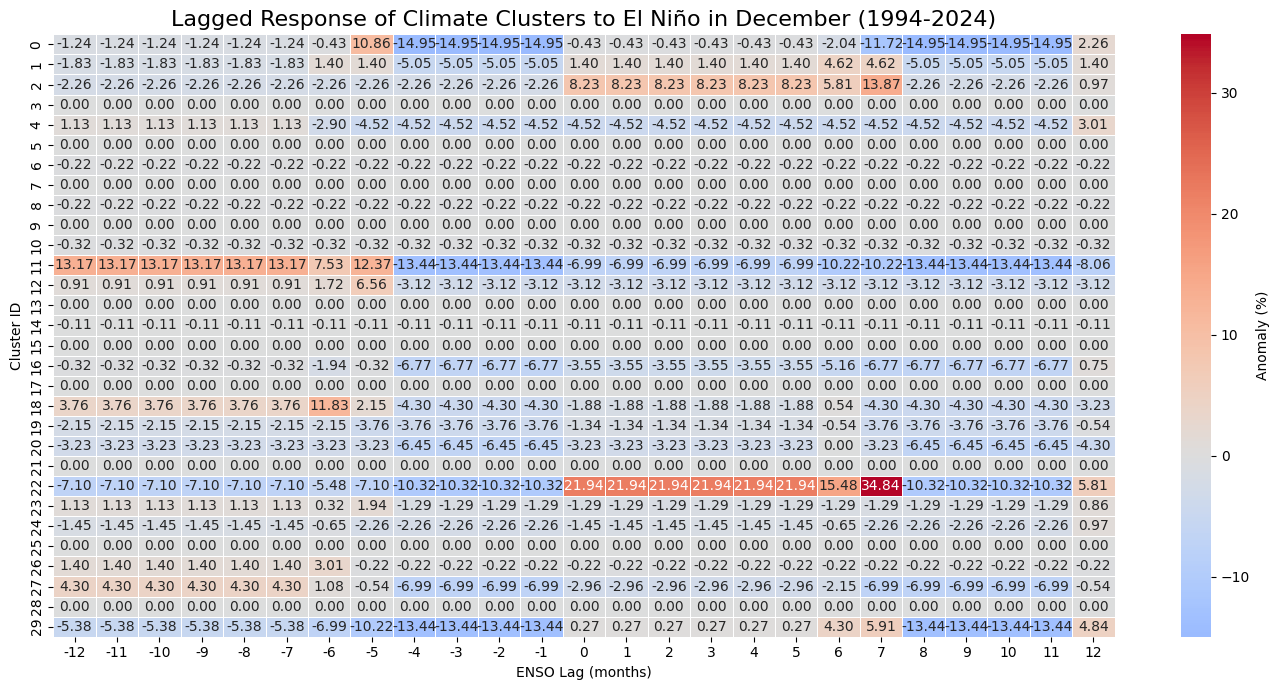

In [27]:

_ENSO_COLS = ['Label', 'ONI', 'is_target', 'label_color']


def _build_lagged_df(df_el_nino, oni_index, lag, year_start=None):
    """Strip existing ENSO columns, re-merge with shifted oni_index, add month col."""
    df = df_el_nino.copy()
    if year_start:
        df = df[df['date'].dt.year >= year_start]
    df = df.drop(columns=_ENSO_COLS, errors='ignore')
    df['month'] = df['date'].dt.month
    return df.merge(oni_index.shift(lag).dropna(),
                    left_on='date_period', right_index=True, how='left')


def _make_pivot(climate_anon, row_name, col_name='Lag'):
    """Convert {(row, lag): value} dict to a pivot DataFrame."""
    anom_df = pd.DataFrame.from_dict(climate_anon, orient='index', columns=['Anomaly'])
    anom_df.index = pd.MultiIndex.from_tuples(anom_df.index, names=[row_name, col_name])
    return anom_df.reset_index().pivot(index=row_name, columns=col_name, values='Anomaly')


def plot_lagged_heatmap_per_cluster(df_el_nino, oni_index,
                                    clusters=[2,22], year_start=None,
                                    comparison_mode='neutral'):
    """Heatmap (Month x Lag) for each target cluster.

    Rows = calendar month, Cols = ENSO lag.
    comparison_mode : 'neutral' or 'climatology'
    """
    if year_start is None:
        year_start = df_el_nino['date'].dt.year.min()
    year_end = df_el_nino['date'].dt.year.max()
    
    for cur_cluster in clusters:
        climate_anon = {}
        for month in range(1, 13):
            for lag in range(-12, 13):
                merged = _build_lagged_df(df_el_nino, oni_index, lag, year_start)
                mask_m = merged['month'] == month

                nino_m = merged[mask_m & (merged['Label'] == 'El Niño')]
                base_m = (merged[mask_m & (merged['Label'] == 'Neutro')]
                          if comparison_mode == 'neutral'
                          else merged[mask_m])

                p_nino = (nino_m['cluster_id'] == cur_cluster).sum() / len(nino_m) * 100 if len(nino_m) > 0 else 0.0
                p_base = (base_m['cluster_id'] == cur_cluster).sum() / len(base_m) * 100 if len(base_m) > 0 else 0.0
                climate_anon[(month, lag)] = p_nino - p_base

        pivot = _make_pivot(climate_anon, row_name='Month')

        plt.figure(figsize=(15, 5))
        sns.heatmap(pivot, cmap='coolwarm', center=0,
                    annot=True, fmt='.2f', linewidths=.5,
                    cbar_kws={'label': 'Anomaly (%)'})
        plt.title(f'Lagged Response of Climate Cluster {cur_cluster} to El Niño per month ({year_start}-{year_end})',
                  fontsize=16)
        plt.ylabel('Month')
        plt.xlabel('ENSO Lag (months)')
        plt.tight_layout()
        plt.show()


def plot_lagged_heatmap_per_month(df_el_nino, oni_index,
                                  months=None, year_start=None,
                                  n_clusters=None, comparison_mode='neutral'):
    """Heatmap (Cluster x Lag) for a specific month.

    Rows = cluster ID, Cols = ENSO lag.
    comparison_mode : 'neutral' or 'climatology'
    """
    if months is None:
        months = [12]
    if n_clusters is None:
        n_clusters = df_el_nino['cluster_id'].nunique()
    if year_start is None:
        year_start = df_el_nino['date'].dt.year.min()
    year_end = df_el_nino['date'].dt.year.max()
    
    for month in months:
        climate_anon = {}
        for cur_cluster in range(n_clusters):
            for lag in range(-12, 13):
                merged = _build_lagged_df(df_el_nino, oni_index, lag, year_start)
                mask_m = merged['month'] == month

                nino_m = merged[mask_m & (merged['Label'] == 'El Niño')]
                
                if comparison_mode == 'neutral':
                    base_m = merged[mask_m & (merged['Label'] == 'Neutro')]
                else:
                    base_m = merged[mask_m] 

                p_nino = (nino_m['cluster_id'] == cur_cluster).sum() / len(nino_m) * 100 if len(nino_m) > 0 else 0.0
                p_base = (base_m['cluster_id'] == cur_cluster).sum() / len(base_m) * 100 if len(base_m) > 0 else 0.0
                climate_anon[(cur_cluster, lag)] = p_nino - p_base

        pivot = _make_pivot(climate_anon, row_name='Cluster')

        month_name = pd.Timestamp(2000, month, 1).strftime('%B')
        plt.figure(figsize=(14, 7))
        sns.heatmap(pivot, cmap='coolwarm', center=0,
                    annot=True, fmt='.2f', linewidths=.5,
                    cbar_kws={'label': 'Anomaly (%)'})
        plt.title(f'Lagged Response of Climate Clusters to El Niño in {month_name} ({year_start}-{year_end})',
                  fontsize=16)
        plt.ylabel('Cluster ID')
        plt.xlabel('ENSO Lag (months)')
        plt.tight_layout()
        plt.show()


# --- Run ---
plot_lagged_heatmap_per_cluster(df, oni_index,clusters=[2, 22,0,25],
                                comparison_mode=COMPARISON_MODE)
plot_lagged_heatmap_per_month(df_el_nino, oni_index, months=[12],
                              comparison_mode=COMPARISON_MODE)

plot_lagged_heatmap_per_cluster(df, oni_index,clusters=[2, 22,0,25],year_start=1994,
                                comparison_mode=COMPARISON_MODE)
plot_lagged_heatmap_per_month(df_el_nino, oni_index, months=[12],year_start=1994,
                              comparison_mode=COMPARISON_MODE)

## 5. December Climate Regimes

Top-80% probability-mass clusters for Climatology and El Niño in December.

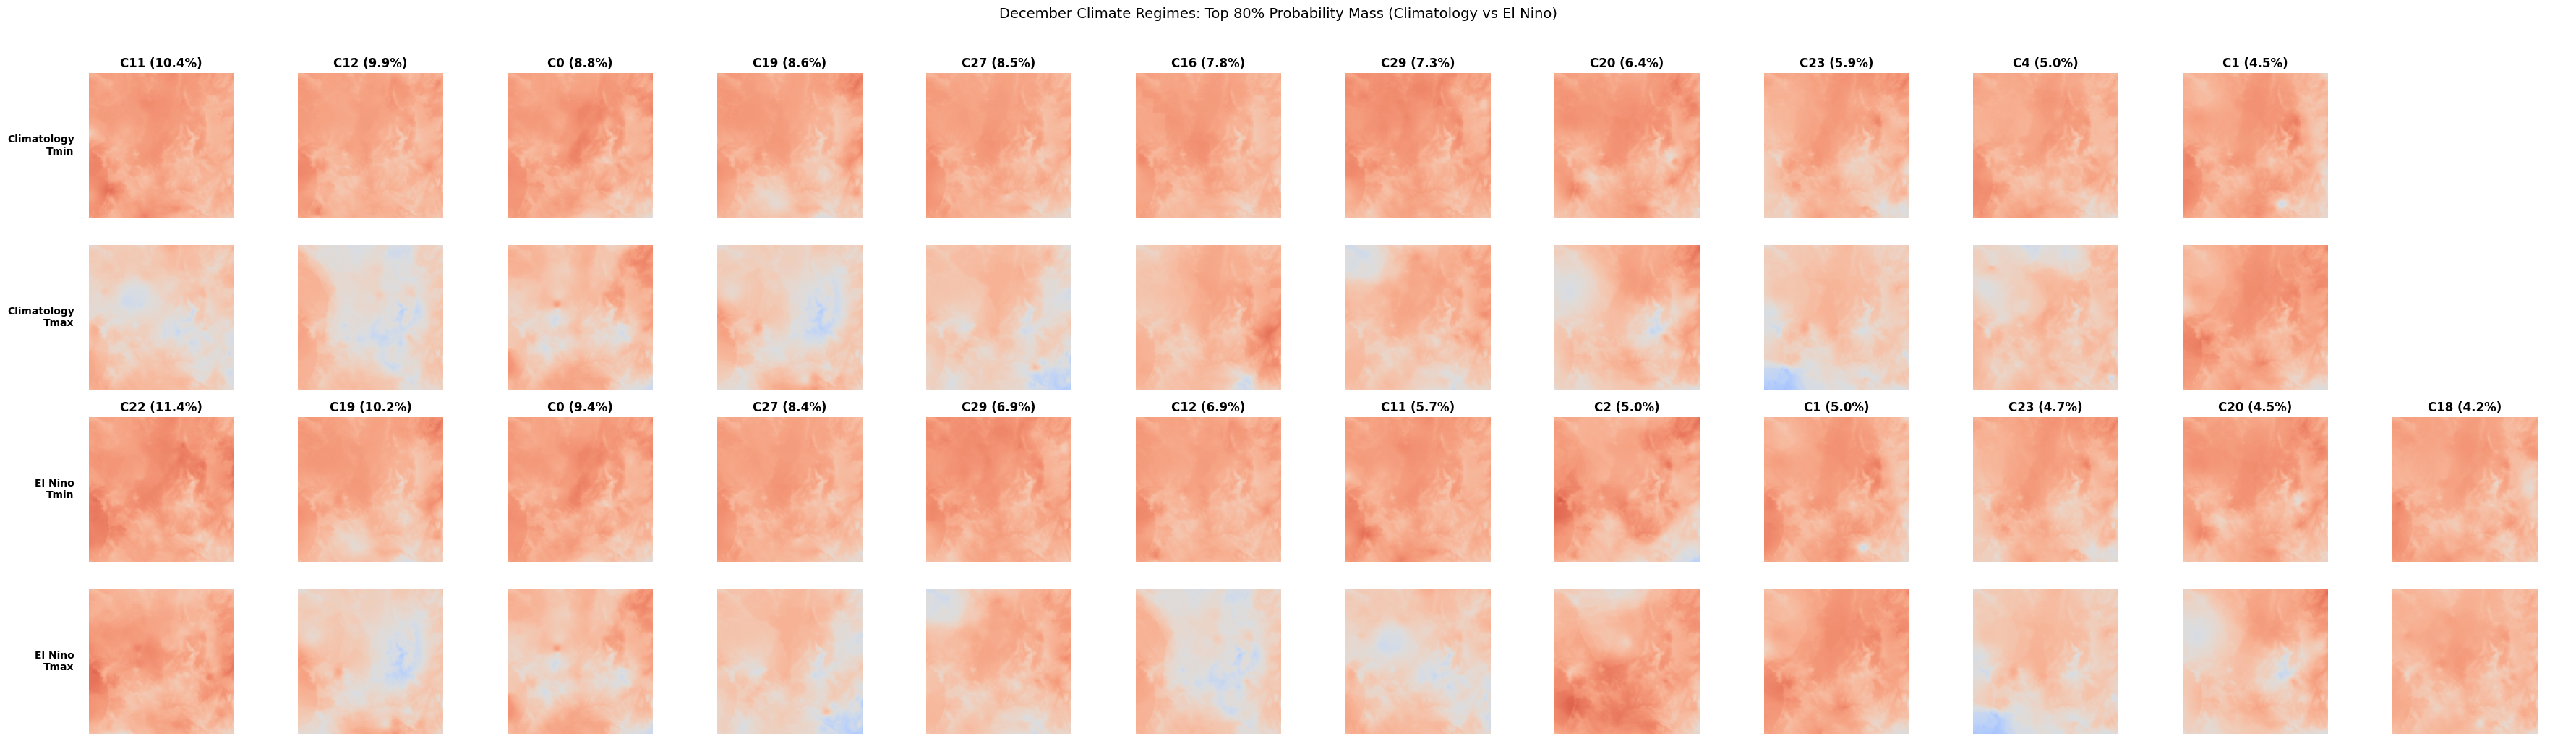

In [28]:
def plot_december_regimes(df_el_nino, combined_dataset, nvars, vars_names, var_stats, month=12):
    """Grid of representative images for the top-80% clusters under two conditions."""
    df_m = df_el_nino[df_el_nino['date'].dt.month == month].copy()

    def get_top_80(df_cond):
        dist   = df_cond['cluster_id'].value_counts(normalize=True)
        cumsum = dist.cumsum()
        top    = [c for c, v in zip(cumsum.index, cumsum) if (len([c]) == 0 or v <= 0.8 + 1e-9)]
        # keep adding until cumsum >= 0.8
        top2 = []
        for c, v in cumsum.items():
            top2.append(c)
            if v >= 0.8:
                break
        return top2, dist

    top_clim, dist_clim = get_top_80(df_m[df_m['Label'] == 'Neutro'])
    top_nino, dist_nino = get_top_80(df_m[df_m['Label'] == 'El Niño'])

    max_cols  = max(len(top_clim), len(top_nino))
    total_rows = 2 * nvars
    fig, axes = plt.subplots(total_rows, max_cols,
                              figsize=(3 * max_cols, 2.5 * total_rows), squeeze=False)

    for row_offset, (top_clusters, dist, row_label) in enumerate([
        (top_clim, dist_clim, 'Climatology'),
        (top_nino, dist_nino, 'El Nino'),
    ]):
        for idx, cluster_id in enumerate(top_clusters):
            sample = df_el_nino[df_el_nino['cluster_id'] == cluster_id].nlargest(1, 'cluster_prob')
            if sample.empty:
                continue
            image_data = combined_dataset[sample.index[0]]
            for var in range(nvars):
                ax = axes[row_offset * nvars + var, idx]
                vmin, vmax = var_stats[var]
                ax.imshow(image_data[var], cmap='coolwarm', vmin=vmin, vmax=vmax)
                ax.axis('off')
                if var == 0:
                    ax.set_title(f'C{cluster_id} ({dist[cluster_id]*100:.1f}%)', fontweight='bold')
                if idx == 0:
                    ax.text(-0.1, 0.5, f'{row_label}\n{vars_names[var]}',
                            transform=ax.transAxes, ha='right', va='center',
                            fontweight='bold', fontsize=10)
        # turn off excess axes
        for idx in range(len(top_clusters), max_cols):
            for var in range(nvars):
                axes[row_offset * nvars + var, idx].axis('off')

    month_name = pd.Timestamp(2000, month, 1).strftime('%B')
    plt.suptitle(
        f'{month_name} Climate Regimes: Top 80% Probability Mass '
        '(Climatology vs El Nino)',
        fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


plot_december_regimes(df_el_nino, combined_dataset, nvars, vars_names, var_stats, month=12)

## 6. Temporal Evolution of Clusters

Moving-average frequency of selected clusters, highlighting El Niño periods.

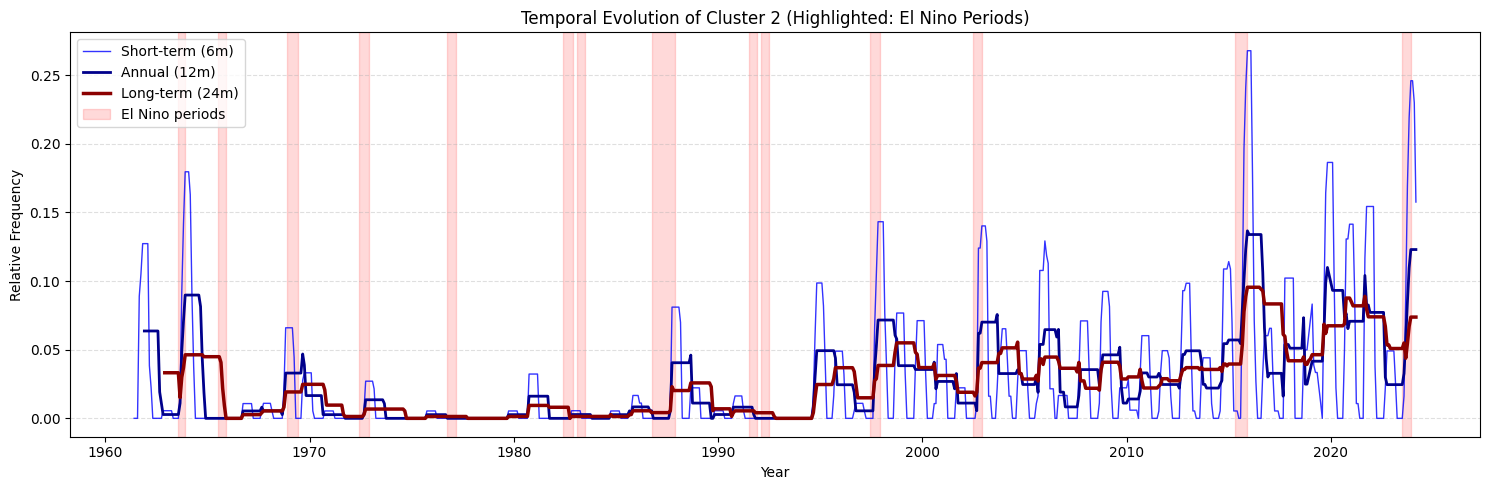

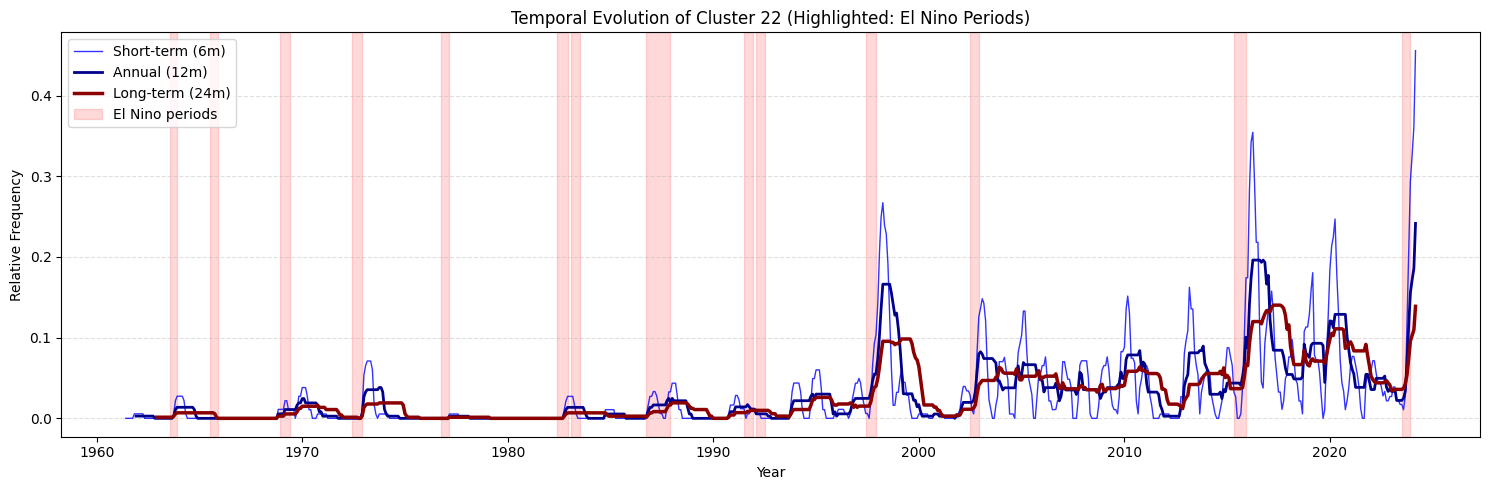

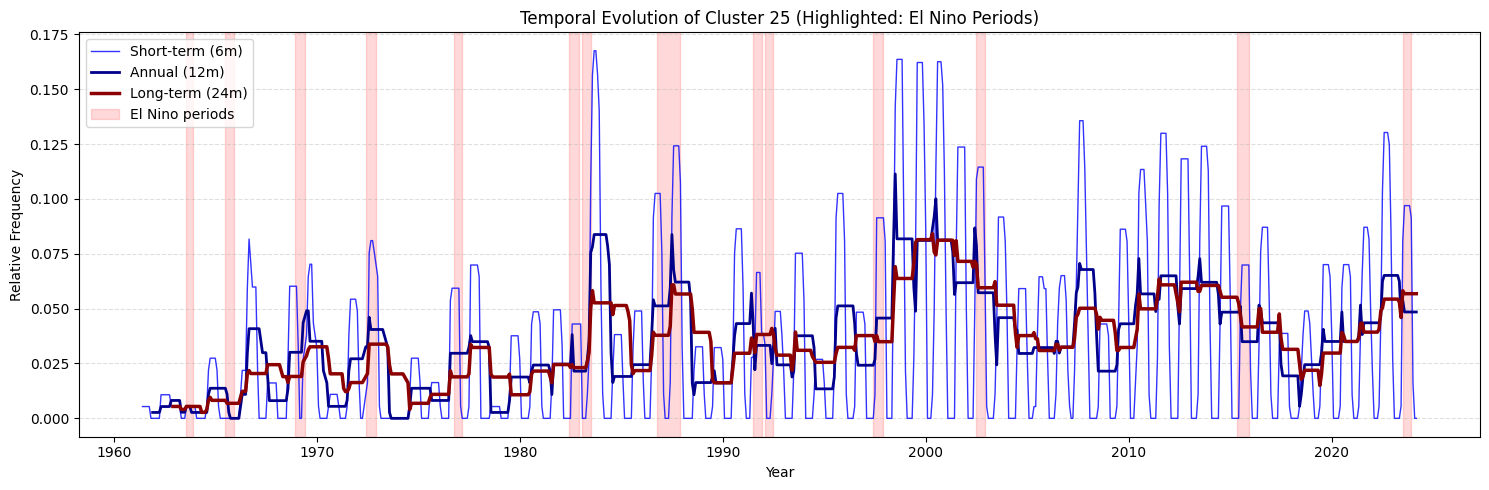

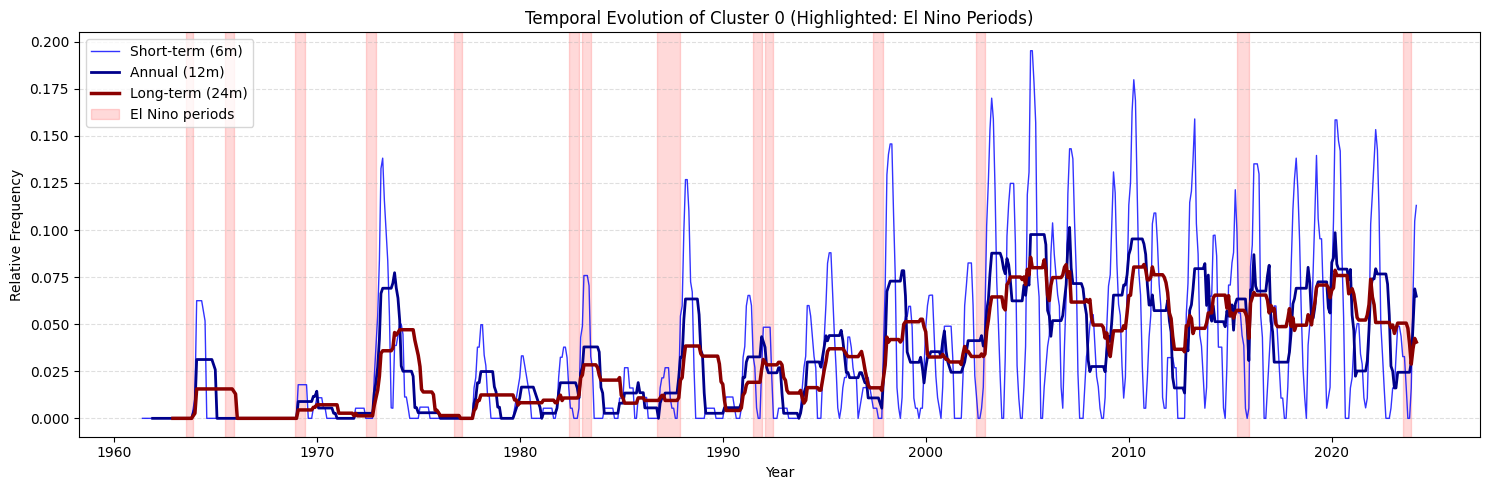

In [29]:
def plot_cluster_temporal_evolution(df_el_nino, target_clusters, windows=(6, 12, 24)):
    """Moving-average frequency of each target cluster with El Nino shading."""
    for target_cluster in target_clusters:
        cur = df_el_nino.copy()
        cur['date'] = pd.to_datetime(cur['date'])
        cur = cur.sort_values('date').set_index('date')
        cur['is_target'] = (cur['cluster_id'] == target_cluster).astype(int)

        monthly = cur.resample('MS').agg({'is_target': 'mean', 'Label': 'first'})

        colors  = ['blue', 'darkblue', 'darkred']
        labels_ = [f'Short-term ({windows[0]}m)', f'Annual ({windows[1]}m)',
                   f'Long-term ({windows[2]}m)']

        plt.figure(figsize=(15, 5))
        for w, color, lbl in zip(windows, colors, labels_):
            plt.plot(monthly.index, monthly['is_target'].rolling(w).mean(),
                     label=lbl, color=color,
                     lw=2.5 if w == windows[-1] else (2 if w == windows[1] else 1),
                     alpha=0.8 if w == windows[0] else 1)

        is_nino = monthly['Label'] == 'El Niño'
        plt.fill_between(monthly.index, 0, 1, where=is_nino, color='red', alpha=0.15,
                         transform=plt.gca().get_xaxis_transform(), label='El Nino periods')

        plt.title(f'Temporal Evolution of Cluster {target_cluster} '
                  '(Highlighted: El Nino Periods)')
        plt.ylabel('Relative Frequency')
        plt.xlabel('Year')
        plt.legend(loc='upper left')
        plt.grid(axis='y', linestyle='--', alpha=0.4)
        plt.tight_layout()
        plt.show()


TARGET_CLUSTERS = [2, 22, 25, 0]
plot_cluster_temporal_evolution(df_el_nino, TARGET_CLUSTERS)
